In [12]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r"D:\Stress Detection\data\WESAD"
CHEST_HZ  = 700

SUBJECT_IDS = ['S2','S3','S4','S5','S6','S7','S8','S9',
               'S10','S11','S13','S14','S15','S16','S17']

def load_subject(data_path, sid):
    pkl_path = os.path.join(data_path, sid, f"{sid}.pkl")
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

subjects = {}
for sid in SUBJECT_IDS:
    try:
        subjects[sid] = load_subject(DATA_PATH, sid)
        print(f"  loaded {sid}")
    except FileNotFoundError:
        print(f"  missing {sid} — skipped")

print(f"\nTotal loaded: {len(subjects)}")

  loaded S2
  loaded S3
  loaded S4
  loaded S5
  loaded S6
  loaded S7
  loaded S8
  loaded S9
  loaded S10
  loaded S11
  loaded S13
  loaded S14
  loaded S15
  loaded S16
  loaded S17

Total loaded: 15


In [13]:
# ── Per-signal statistical features ─────────────────────────────────────────
def signal_features(sig, name):
    """Extract 7 statistical features from a 1D signal array."""
    sig = sig.flatten()
    return {
        f'{name}_mean'     : np.mean(sig),
        f'{name}_std'      : np.std(sig),
        f'{name}_min'      : np.min(sig),
        f'{name}_max'      : np.max(sig),
        f'{name}_range'    : np.max(sig) - np.min(sig),
        f'{name}_skew'     : skew(sig),
        f'{name}_kurtosis' : kurtosis(sig),
    }

# ── HRV features from ECG ────────────────────────────────────────────────────
def hrv_features(ecg_window):
    """
    Estimate basic HRV from ECG.
    Finds R-peaks, computes RR intervals, returns mean/std/RMSSD.
    """
    ecg = ecg_window.flatten()
    # normalize before peak detection
    ecg_norm = (ecg - np.mean(ecg)) / (np.std(ecg) + 1e-8)
    peaks, _ = find_peaks(ecg_norm, distance=int(CHEST_HZ * 0.4),
                          height=0.3)
    if len(peaks) < 3:
        return {'hrv_mean_rr': 0.0, 'hrv_std_rr': 0.0, 'hrv_rmssd': 0.0}

    rr = np.diff(peaks) / CHEST_HZ * 1000  # ms
    rmssd = np.sqrt(np.mean(np.diff(rr) ** 2))
    return {
        'hrv_mean_rr': np.mean(rr),
        'hrv_std_rr' : np.std(rr),
        'hrv_rmssd'  : rmssd,
    }

# ── Master feature extractor for one window ──────────────────────────────────
def extract_features(chest_window):
    """
    chest_window: dict with keys ECG, EDA, Temp, Resp, EMG, ACC
    Returns flat feature dict.
    """
    feats = {}

    # Statistical features for each signal
    for sig_name in ['ECG', 'EDA', 'Temp', 'Resp', 'EMG']:
        feats.update(signal_features(chest_window[sig_name], sig_name))

    # ACC — magnitude + per-axis
    acc = chest_window['ACC']           # shape: (N, 3)
    acc_mag = np.linalg.norm(acc, axis=1)
    feats.update(signal_features(acc_mag, 'ACC_mag'))
    for i, axis in enumerate(['x', 'y', 'z']):
        feats.update(signal_features(acc[:, i], f'ACC_{axis}'))

    # HRV from ECG
    feats.update(hrv_features(chest_window['ECG']))

    return feats

print("Feature extraction functions defined.")
print("Features per window:", len(extract_features(
    {k: np.random.randn(CHEST_HZ * 10, 1) if k != 'ACC'
     else np.random.randn(CHEST_HZ * 10, 3)
     for k in ['ECG','EDA','Temp','Resp','EMG','ACC']}
)))

Feature extraction functions defined.
Features per window: 66


In [14]:
# ── Window parameters ────────────────────────────────────────────────────────
# 10 seconds per window, 5 second step (50% overlap)
WINDOW_SIZE = CHEST_HZ * 10   # 7000 samples
STEP_SIZE   = CHEST_HZ * 5    # 3500 samples

# Labels to keep: 1=baseline(non-stress), 2=stress, 3=amusement(non-stress)
# Map: 2→1 (stress),  1&3→0 (non-stress),  0&4→skip

def label_window(label_segment):
    """
    Returns 0 (non-stress), 1 (stress), or -1 (skip).
    A window is labeled by majority vote, only if >80% of samples
    belong to a single class (stress or non-stress).
    """
    valid_mask = np.isin(label_segment, [1, 2, 3])
    if np.mean(valid_mask) < 0.8:
        return -1   # too many transient/meditation samples → skip

    valid_labels = label_segment[valid_mask]
    stress_ratio = np.mean(valid_labels == 2)

    if stress_ratio > 0.5:
        return 1    # stress
    else:
        return 0    # non-stress

# ── Main extraction loop ─────────────────────────────────────────────────────
all_features = []
all_labels   = []
all_subjects = []

for sid, data in subjects.items():
    chest  = data['signal']['chest']
    labels = data['label']
    n      = len(labels)

    windows_this_subject = 0

    for start in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE

        window_labels = labels[start:end]
        y = label_window(window_labels)

        if y == -1:
            continue    # skip mixed/transient windows

        # Slice chest signals for this window
        chest_window = {}
        for key in ['ECG', 'EDA', 'Temp', 'Resp', 'EMG']:
            chest_window[key] = chest[key][start:end]
        chest_window['ACC'] = chest['ACC'][start:end]

        feats = extract_features(chest_window)
        all_features.append(feats)
        all_labels.append(y)
        all_subjects.append(sid)
        windows_this_subject += 1

    print(f"  {sid}: {windows_this_subject} windows extracted")

# ── Convert to DataFrame ─────────────────────────────────────────────────────
X_df = pd.DataFrame(all_features)
y    = np.array(all_labels)
subs = np.array(all_subjects)

print(f"\nTotal windows : {len(y)}")
print(f"Stress (1)    : {np.sum(y==1)}  ({np.mean(y==1)*100:.1f}%)")
print(f"Non-stress (0): {np.sum(y==0)}  ({np.mean(y==0)*100:.1f}%)")
print(f"Feature count : {X_df.shape[1]}")
print(f"\nX shape: {X_df.shape}")

  S2: 421 windows extracted
  S3: 427 windows extracted
  S4: 430 windows extracted
  S5: 438 windows extracted
  S6: 436 windows extracted
  S7: 436 windows extracted
  S8: 436 windows extracted
  S9: 435 windows extracted
  S10: 450 windows extracted
  S11: 441 windows extracted
  S13: 441 windows extracted
  S14: 442 windows extracted
  S15: 444 windows extracted
  S16: 441 windows extracted
  S17: 451 windows extracted

Total windows : 6569
Stress (1)    : 1972  (30.0%)
Non-stress (0): 4597  (70.0%)
Feature count : 66

X shape: (6569, 66)


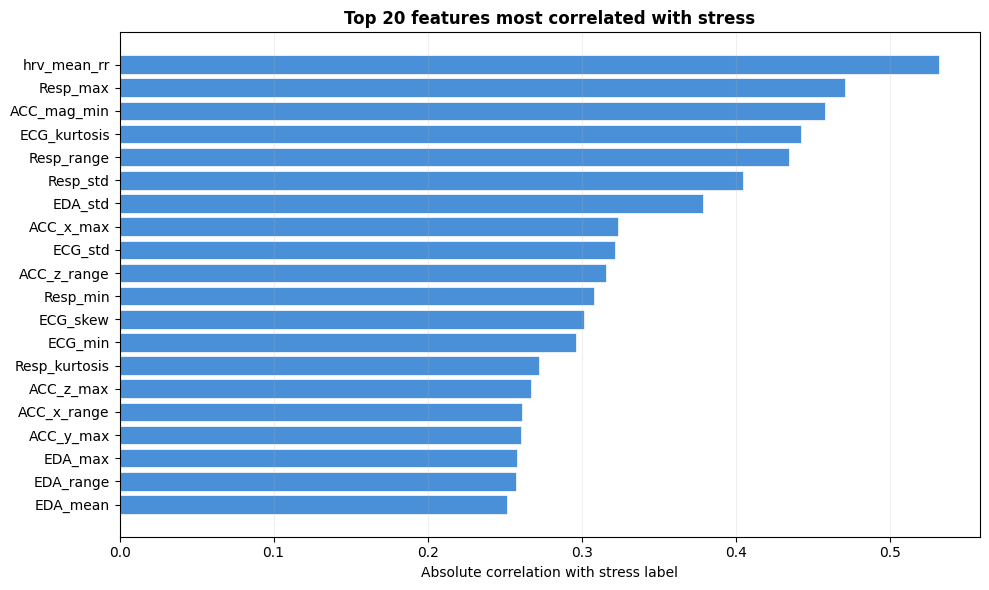

Top 5 features:
hrv_mean_rr     0.532081
Resp_max        0.470999
ACC_mag_min     0.458076
ECG_kurtosis    0.442379
Resp_range      0.434732
Name: label, dtype: float64


In [15]:
import matplotlib.pyplot as plt

# Top 20 features correlated with label
X_numeric = X_df.copy()
X_numeric['label'] = y

corr_with_label = X_numeric.corr()['label'].drop('label').abs().sort_values(ascending=False)
top20 = corr_with_label.head(20)

plt.figure(figsize=(10, 6))
bars = plt.barh(top20.index[::-1], top20.values[::-1],
                color='#4a90d9', edgecolor='white', linewidth=0.5)
plt.xlabel('Absolute correlation with stress label')
plt.title('Top 20 features most correlated with stress', fontweight='bold')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_PATH), 'feature_correlation.png'),
            dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(top20.head())

In [16]:
from sklearn.preprocessing import StandardScaler

# ── Handle any NaN/inf from HRV calculation ──────────────────────────────────
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_df.fillna(X_df.median(), inplace=True)

X = X_df.values

# ── Scale features ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Save everything needed for NB03 ─────────────────────────────────────────
SAVE_PATH = os.path.dirname(DATA_PATH)  # D:\StressDetection\

np.save(os.path.join(SAVE_PATH, 'X_scaled.npy'),   X_scaled)
np.save(os.path.join(SAVE_PATH, 'y.npy'),           y)
np.save(os.path.join(SAVE_PATH, 'subjects.npy'),    subs)

import joblib
joblib.dump(scaler,           os.path.join(SAVE_PATH, 'scaler.pkl'))
joblib.dump(list(X_df.columns), os.path.join(SAVE_PATH, 'feature_names.pkl'))

print("Saved:")
print(f"  X_scaled.npy     → {X_scaled.shape}")
print(f"  y.npy            → {y.shape}")
print(f"  subjects.npy     → {subs.shape}")
print(f"  scaler.pkl")
print(f"  feature_names.pkl")
print(f"\nNB02 complete ✓  →  proceed to NB03")

Saved:
  X_scaled.npy     → (6569, 66)
  y.npy            → (6569,)
  subjects.npy     → (6569,)
  scaler.pkl
  feature_names.pkl

NB02 complete ✓  →  proceed to NB03
